# GRA: lion + imgnet + ResNet18 + GR

project = ```GRA```, host = ```yoru```, device = ```cuda:0```

## Goals:

Test these Lion extensions:

**general relativistic**

on `ImageNet` w/ `ResNet18` architectrue

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: yoru

## Main

In [3]:
from optimzers import *
from test.test import *

### ImgNet32

`batch_size = 256`

In [4]:
cfg = TrainConfig(
    dataset='ImageNet32',
    batch_size=256,
    epochs=100,
    device=device,
    data_on_device=False,
    verbose=True,
    amp=False,
)

In [5]:
lr = 1e-3


experiments = [
    Experiment(
        f"GR. Lion — mass={m},gamma={g},betas=({b1},0.99),b3={b3}",
        make_opt(GeneralRelativisticLion, lr=lr, mass=m, gamma=g, beta_gravity=b3, betas=(b1, 0.99)),
    ) for m, g, b1, b3 in itertools.product([100], [0.1], [0.8, 0.9], [0.99])
]

experiments.extend([Experiment(
    f"Adam — b1={b1}",
    make_opt(torch.optim.Adam, lr=1e-3, betas=(b1, 0.99)),
) for b1 in [0.8, 0.9]])

print(experiments)

[
    Experiment(
        name='GR. Lion — mass=100,gamma=0.1,betas=(0.8,0.99),b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7fbbbf51f740>
    ),
    Experiment(
        name='GR. Lion — mass=100,gamma=0.1,betas=(0.9,0.99),b3=0.99',
        opt_fn=<function make_opt.<locals>._fn at 0x7fbbbf51f4c0>
    ),
    Experiment(name='Adam — b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x7fbbbf51f560>),
    Experiment(name='Adam — b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x7fbbbf51f1a0>)
]

In [6]:
results = run_experiments(
    experiments=experiments,
    cfg=cfg,
    model_class=ResNet18,
    model_kws=dict(num_classes=1000),
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ResNet18({'num_classes': 1000}) | seed=0
Optimizer: GeneralRelativisticLion

GeneralRelativisticLion (
Parameter Group 0
    beta_gravity: 0.99
    betas: (0.8, 0.99)
    gamma: 0.1
    lr: 0.001
    mass: 100
    weight_decay: 0.0
)

Epoch    1/100:  Train Loss 4.3528  |  Test Acc 26.17%

Epoch    5/100:  Train Loss 2.0448  |  Test Acc 37.14%

Epoch   10/100:  Train Loss 1.1265  |  Test Acc 33.55%

...

Epoch   85/100:  Train Loss 0.0651  |  Test Acc 32.81%

Epoch   90/100:  Train Loss 0.0621  |  Test Acc 32.75%

Epoch   95/100:  Train Loss 0.0585  |  Test Acc 32.66%

Epoch  100/100:  Train Loss 0.0556  |  Test Acc 32.64%

Finished in 23790.0s

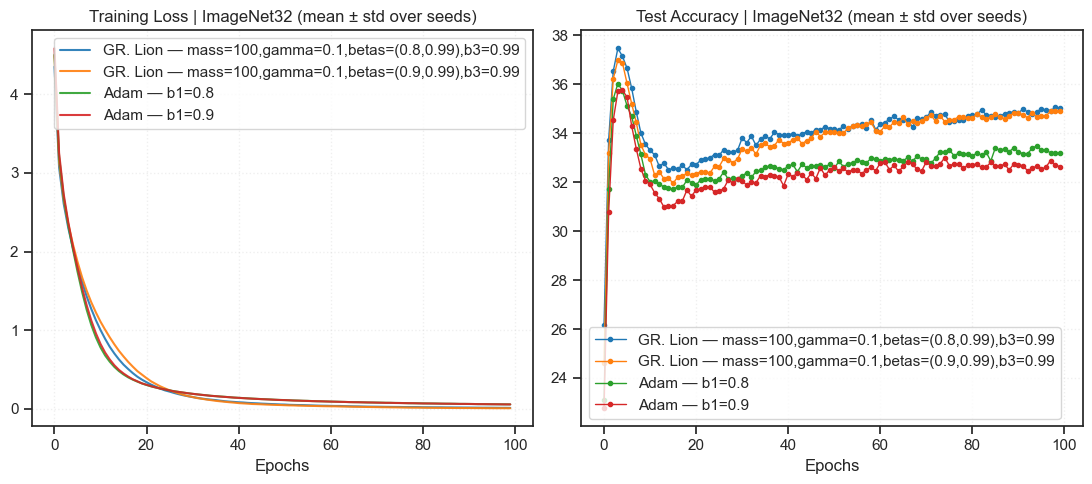

In [7]:
plot_results(results, title="ImageNet32 (mean ± std over seeds)")

In [8]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Adam — b1=0.9': 32.67,
 'Adam — b1=0.8': 33.24,
 'GR. Lion — mass=100,gamma=0.1,betas=(0.9,0.99),b3=0.99': 34.82,
 'GR. Lion — mass=100,gamma=0.1,betas=(0.8,0.99),b3=0.99': 34.99}